# The Price is Right

Today we build a more complex solution for estimating prices of goods.

1. Day 2.0 notebook: create a RAG database with our 400,000 training data
2. Day 2.1 notebook: visualize in 2D
3. Day 2.2 notebook: visualize in 3D
4. Day 2.3 notebook: build and test a RAG pipeline with GPT-4o-mini
5. Day 2.4 notebook: (a) bring back our Random Forest pricer (b) Create a Ensemble pricer that allows contributions from all the pricers

Phew! That's a lot to get through in one day!

## PLEASE NOTE:

We already have a very powerful product estimator with our proprietary, fine-tuned LLM. Most people would be very satisfied with that! The main reason we're adding these extra steps is to deepen your expertise with RAG and with Agentic workflows.

## Finishing off with Random Forests & Ensemble

In [1]:
# imports

import os
import re
import math
import json
from tqdm import tqdm
import random
from dotenv import load_dotenv
from huggingface_hub import login
import numpy as np
import pickle
from openai import OpenAI
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
import chromadb
from items import Item
from testing import Tester
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib


In [2]:
# CONSTANTS

QUESTION = "How much does this cost to the nearest dollar?\n\n"
DB = "products_vectorstore"

In [3]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

In [4]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Token has not been saved to git credential helper.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub.
Run the following command in your terminal in case you want to set the 'store' credential helper as default.

git config --global credential.helper store

Read https://git-scm.com/book/en/v2/Git-Tools-Credential-Storage for more details.


In [5]:
# Another import after Logging in to Hugging Face - thank you Trung N.!

from items import Item

In [6]:
# Load in the test pickle file:

with open('test.pkl', 'rb') as file:
    test = pickle.load(file)

In [7]:
client = chromadb.PersistentClient(path=DB)
collection = client.get_or_create_collection('products')

In [8]:
result = collection.get(include=['embeddings', 'documents', 'metadatas'])
vectors = np.array(result['embeddings'])
documents = result['documents']
prices = [metadata['price'] for metadata in result['metadatas']]

# Random Forest

We will now train a Random Forest model.

Can you spot the difference from what we did in Week 6? In week 6 we used the word2vec model to form vectors; this time we'll use the vectors we already have in Chroma, from the SentenceTransformer model.

In [9]:
# This next line takes an hour on my M1 Mac!

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(vectors, prices)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [10]:
# Save the model to a file

joblib.dump(rf_model, 'random_forest_model.pkl')

['random_forest_model.pkl']

In [11]:
# Load it back in again

rf_model = joblib.load('random_forest_model.pkl')

In [12]:
from agents.specialist_agent import SpecialistAgent
from agents.frontier_agent import FrontierAgent
from agents.random_forest_agent import RandomForestAgent

In [13]:
specialist = SpecialistAgent()
frontier = FrontierAgent(collection)
random_forest = RandomForestAgent()

In [14]:
def description(item):
    return item.prompt.split("to the nearest dollar?\n\n")[1].split("\n\nPrice is $")[0]

In [15]:
def rf(item):
    return random_forest.price(description(item))

/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


1: Guess: $295.95 Truth: $374.41 Error: $78.46 SLE: 0.05 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $203.49 Truth: $225.11 Error: $21.62 SLE: 0.01 Item: Motorcraft YB3125 Fan Clutch
3: Guess: $207.38 Truth: $61.68 Error: $145.70 SLE: 1.44 Item: Dorman 603-159 Front Washer Fluid Reserv...
4: Guess: $378.90 Truth: $599.99 Error: $221.09 SLE: 0.21 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $200.92 Truth: $16.99 Error: $183.93 SLE: 5.85 Item: 5-Position Super Switch Pickup Selector ...


/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdp

6: Guess: $58.98 Truth: $31.99 Error: $26.99 SLE: 0.36 Item: Horror Bookmarks, Resin Horror Bookmarks...
7: Guess: $258.06 Truth: $101.79 Error: $156.27 SLE: 0.85 Item: SK6241 - Stinger 4 Gauge 6000 Series Pow...
8: Guess: $226.22 Truth: $289.00 Error: $62.78 SLE: 0.06 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $307.17 Truth: $635.86 Error: $328.69 SLE: 0.53 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $165.96 Truth: $65.99 Error: $99.97 SLE: 0.83 Item: HOLDWILL 6 Pack LED Shop Light, 4FT 24W ...
11: Guess: $272.49 Truth: $254.21 Error: $18.28 SLE: 0.00 Item: Viking Horns V103C/1005ATK 3 Gallon Air ...
12: Guess: $269.22 Truth: $412.99 Error: $143.77 SLE: 0.18 Item: CURT 70110 Custom Tow Bar Base Plate Bra...


/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdp

...

238: Guess: $201.62 Truth: $425.00 Error: $223.38 SLE: 0.55 Item: Fleck 2510 Timer Mechanical Filter Contr...
239: Guess: $271.86 Truth: $249.99 Error: $21.87 SLE: 0.01 Item: Haloview MC7108 Wireless RV Backup Camer...
240: Guess: $168.46 Truth: $138.23 Error: $30.23 SLE: 0.04 Item: Schmidt Spiele - Manhattan
241: Guess: $183.42 Truth: $414.99 Error: $231.57 SLE: 0.66 Item: Corsa 14333 Tip Kit (Ford Mustang GT)
242: Guess: $215.24 Truth: $168.28 Error: $46.96 SLE: 0.06 Item: Hoshizaki FM116A Fan Motor Kit 1
243: Guess: $201.53 Truth: $199.99 Error: $1.54 SLE: 0.00 Item: BAINUO Antler Chandelier Lighting,6 Ligh...


/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdp

244: Guess: $224.72 Truth: $126.70 Error: $98.02 SLE: 0.32 Item: DNA MOTORING HL-OH-FEXP06-SM-AM Smoke Le...
245: Guess: $180.02 Truth: $5.91 Error: $174.11 SLE: 10.66 Item: Wera Stainless 3840/1 TS 2.5mm Hex Inser...
246: Guess: $213.26 Truth: $193.06 Error: $20.20 SLE: 0.01 Item: Celestron - PowerSeeker 127EQ Telescope ...
247: Guess: $288.82 Truth: $249.99 Error: $38.83 SLE: 0.02 Item: NHOPEEW 10.1inch Android Car Radio Carpl...
248: Guess: $248.70 Truth: $64.12 Error: $184.58 SLE: 1.81 Item: Other Harmonica (Suzuki-2Timer24- A)
249: Guess: $239.39 Truth: $114.99 Error: $124.40 SLE: 0.53 Item: Harley Air Filter Venturi Intake Air Cle...


/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdp

250: Guess: $316.51 Truth: $926.00 Error: $609.49 SLE: 1.15 Item: Elite Screens Edge Free Ambient Light Re...


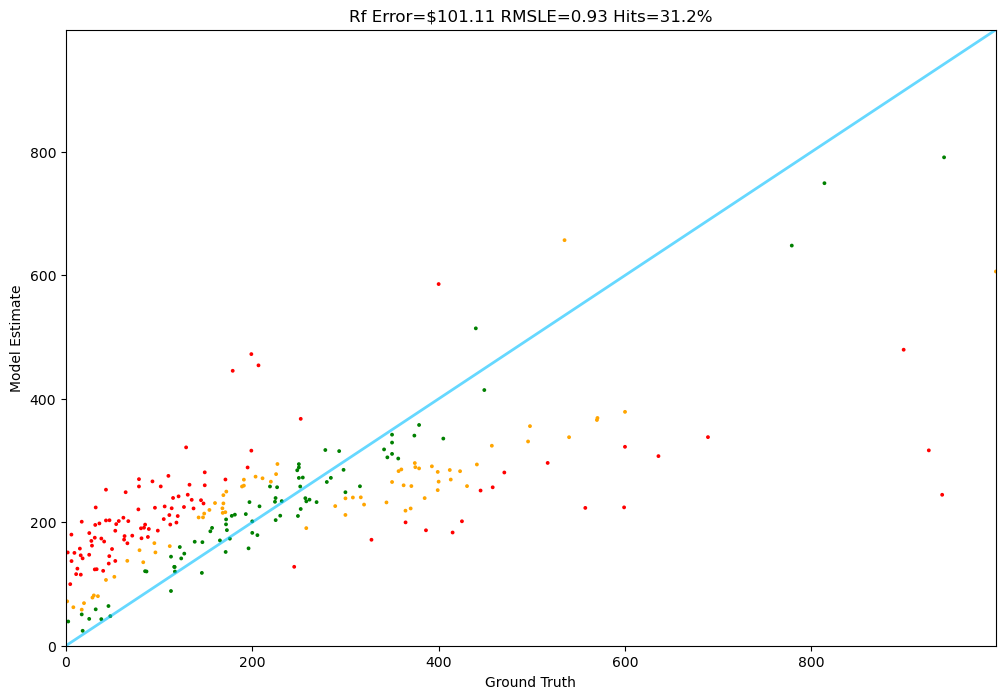

In [16]:
Tester.test(rf, test)

In [17]:
product = "Quadcast HyperX condenser mic for high quality audio for podcasting"

In [18]:
print(specialist.price(product))
print(frontier.price(product))
print(random_forest.price(product))

189.0


/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


195.19
260.67870000000016


In [19]:
specialists = []
frontiers = []
random_forests = []
prices = []
for item in tqdm(test[1000:1250]):
    text = description(item)
    specialists.append(specialist.price(text))
    frontiers.append(frontier.price(text))
    random_forests.append(random_forest.price(text))
    prices.append(item.price)

  0%|          | 0/250 [00:00<?, ?it/s]/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
  0%|          | 1/250 [00:03<14:07,  3.40s/it]/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
  1%|          | 2/250 [00:06<13:16,  3.21s/it]/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
  1%|          | 3/250 [00:09<13:34,  3.30s/it]/home/nishihara/anacon

In [20]:
mins = [min(s,f,r) for s,f,r in zip(specialists, frontiers, random_forests)]
maxes = [max(s,f,r) for s,f,r in zip(specialists, frontiers, random_forests)]

X = pd.DataFrame({
    'Specialist': specialists,
    'Frontier': frontiers,
    'RandomForest': random_forests,
    'Min': mins,
    'Max': maxes,
})

# Convert y to a Series
y = pd.Series(prices)

In [21]:
# Train a Linear Regression
np.random.seed(42)

lr = LinearRegression()
lr.fit(X, y)

feature_columns = X.columns.tolist()

for feature, coef in zip(feature_columns, lr.coef_):
    print(f"{feature}: {coef:.2f}")
print(f"Intercept={lr.intercept_:.2f}")

Specialist: 0.42
Frontier: 0.15
RandomForest: -0.42
Min: 0.41
Max: 0.40
Intercept=25.05


In [22]:
joblib.dump(lr, 'ensemble_model.pkl')

['ensemble_model.pkl']

In [23]:
from agents.ensemble_agent import EnsembleAgent
ensemble = EnsembleAgent(collection)

In [24]:
ensemble.price(product)

/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


206.27053841031002

In [25]:
def ensemble_pricer(item):
    return max(0,ensemble.price(description(item)))

/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


1: Guess: $407.42 Truth: $374.41 Error: $33.01 SLE: 0.01 Item: OEM AC Compressor w/A/C Repair Kit For F...


/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


2: Guess: $202.31 Truth: $225.11 Error: $22.80 SLE: 0.01 Item: Motorcraft YB3125 Fan Clutch


/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


...

248: Guess: $81.46 Truth: $64.12 Error: $17.34 SLE: 0.06 Item: Other Harmonica (Suzuki-2Timer24- A)


/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


249: Guess: $183.14 Truth: $114.99 Error: $68.15 SLE: 0.21 Item: Harley Air Filter Venturi Intake Air Cle...


/home/nishihara/anaconda3/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


250: Guess: $630.43 Truth: $926.00 Error: $295.57 SLE: 0.15 Item: Elite Screens Edge Free Ambient Light Re...


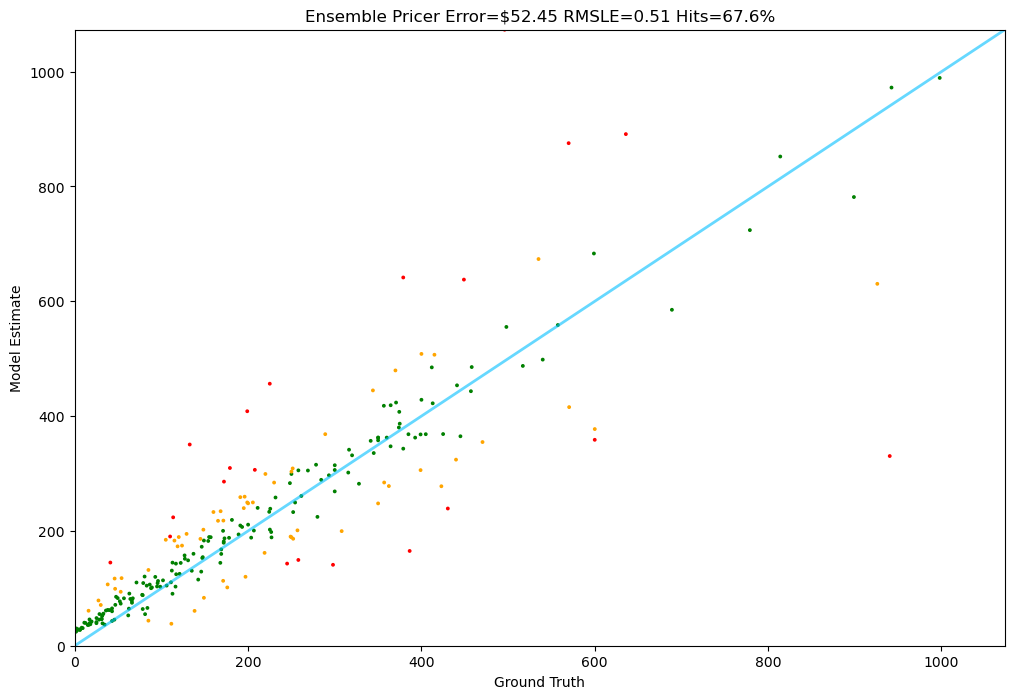

In [27]:
Tester.test(ensemble_pricer, test)

Well, result was not so good, it was worser then frontier and specialist.

# WHAT A DAY!

We got so much done - a Fronter RAG pipeline, a Random Forest model using transformer-based encodings, and an Ensemble model.

You can do better, for sure!

Tweak this, and try adding components into the ensemble, to beat my performance.